### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

![image.png](attachment:image.png)

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches '

In [7]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"

In [8]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv,wiki,add,multiply,divide]

In [9]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\bhara\AppData\Local\Temp\ipykernel_13564\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [10]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'GPT 4.5 is out! — Weekly AI Newsletter (March 3rd 2025) - Medium',
  'url': 'https://medium.com/nlplanet/gpt-4-5-is-out-weekly-ai-newsletter-march-3rd-2025-6b31dd83ca60',
  'content': 'Anthropic releases Claude 3.7 Sonnet, OpenAI expands Deep Research for Plus users, and Google launches new code assistant.',
  'score': 0.9170729},
 {'title': 'Top 5 AI trends in March 2025: AI agents, smarter supply chains, and more\xa0 - Neudesic',
  'url': 'https://www.neudesic.com/blog/top-5-ai-trends-march-2025/',
  'content': 'World Foundation Models and robotics are becoming a greater focus area for companies like NVIDIA and Google that are pushing the boundaries of physical AI. Gemini Robotics demonstrates Google’s investment in physical AI by creating models focused on adapting to novel situations, understanding diverse instructions, and manipulating objects with fine-grain motor capabilities. Integrating Gemini’s robust language understanding with motor capabilities allows people to

In [11]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily,add,divide,multiply]

In [14]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

In [15]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent AI News". Likely they want a summary of recent AI news. We need up-to-date info. We have a search tool tavily_search_results_json for current events. Use that with query "recent AI news".', 'tool_calls': [{'id': 'fc_98f77f00-a97a-4706-a11e-045468270527', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 378, 'total_tokens': 465, 'completion_time': 0.205599061, 'completion_tokens_details': {'reasoning_tokens': 54}, 'prompt_time': 0.01371912, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.050629573, 'total_time': 0.219318181}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db068-d95a-7

In [16]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news 2024 April'},
  'id': 'fc_da60bc06-c9a6-4950-954e-74c00a1a488d',
  'type': 'tool_call'}]

In [17]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

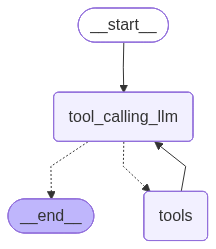

In [18]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [19]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_a2360f35-38df-40e7-9132-6bd3aa097e29)
 Call ID: fc_a2360f35-38df-40e7-9132-6bd3aa097e29
  Args:
    query: AI news March 3 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "March 2025 - The Artificial Intelligence Revolution - Choreo Advisors", "url": "https://choreoadvisors.com/market-perspectives/march-2025-the-artificial-intelligence-revolution/", "content": "There are plenty of signs that AI is beginning to have a material effect on the world. One of the early signals may be the valuation of AI-related private companies such as OpenAI. Investors are willing to pay up for what they believe could be a potent

In [20]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on building systems that can **learn from data** and improve their performance on a task without being explicitly programmed for every possible scenario. In other words, instead of writing fixed rules that dictate how a computer should behave, we give the computer examples (data) and let it infer the underlying patterns, relationships, or decision boundaries that allow it to make predictions or take actions on new, unseen inputs.

---

## Core Idea

1. **Data → Model → Prediction/Decision**  
   - **Data**: A collection of examples (e.g., images, text, sensor readings) that contain inputs and, often, known outputs (labels).  
   - **Model**: A mathematical or computational structure (e.g., a linear equation, a neura

### Agent Memory
#### Aim
Lets introduce Agent With Memory

In [21]:
messages=graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================

5 + 8 = 13.


In [22]:
messages=[HumanMessage(content="Divide that by 5")]
messages=graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

I’m not sure what value you’d like to divide by 5. Could you please provide the number (or expression) you want to have divided?


#### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

![image.png](attachment:image.png)

In [29]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")
llm_with_tools = llm.bind_tools(tools)

In [30]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")

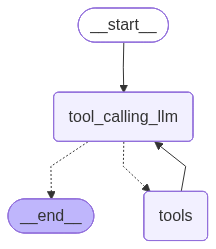

In [31]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

# View
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [32]:
## Specify the thread

config={"configurable":{"thread_id":"1"}}
# Specify an input
messages = [HumanMessage(content="Add 12 and 13.")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_3756d6d3-7193-48c8-a5ef-1382bdd6db71)
 Call ID: fc_3756d6d3-7193-48c8-a5ef-1382bdd6db71
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.


In [33]:
messages = [HumanMessage(content="then multiplty that number by 2")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_3756d6d3-7193-48c8-a5ef-1382bdd6db71)
 Call ID: fc_3756d6d3-7193-48c8-a5ef-1382bdd6db71
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.
================================ Human Message =================================

then multiplty that number by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_46b76519-0b76-40c7-982d-b34c40cc3f30)
 Call ID: fc_46b76519-0b76-40c7-982d-b34c40cc3f30
  Args:
    a: 25
    b: 2
================================= Tool Message =================================
Name: multiply

50
================================== Ai 